# `MVG_advanced.ipynb` -- Advanced MVG Pipeline
## Statistical Models - Business Case 4 -- Early Warning System

**Architecture: 4-stage pipeline**

```
Walk-Forward Split  (temporal 60 / 20 / 20)
        |
[Stage 1]  EVT / POT Threshold
           Generalized Pareto Distribution on the tail of normal training scores
           Threshold set at a fixed false-alarm rate (5 % / week)
        |
[Stage 2]  Directional Filter
           PCA risk-off direction -- suppress boom / risk-on anomalies
        |
[Stage 3]  Group Decomposition  (Graphical Lasso only)
           Per-group Mahalanobis scores: Equity - Credit - Rates - FX - Macro
        |
[Stage 4]  Lead Time Analysis
           Weeks of advance warning before each crisis onset
```

**Models:** Elliptic Envelope - Student-t (nu=2) - Graphical Lasso

**Why this design:**
The split-comparison analysis (`ANALYSIS_Split_Comparison.md`) shows that AUC is
stable (0.76-0.83) across all split methodologies, but F1 collapses in temporal
splits because the F1-optimised threshold does not transfer across regimes.
This notebook addresses three distinct problems:
- **Threshold non-stationarity** -- replaced by EVT/POT calibrated on the normal tail
- **Boom / crisis symmetry** -- directional filter on the risk-off PCA direction
- **Operational relevance** -- lead time as primary evaluation metric

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto, multivariate_t
from sklearn.covariance import EllipticEnvelope, GraphicalLassoCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})
print("All imports successful.")

All imports successful.


In [2]:
from pathlib import Path as _P

def _find_dataset():
    for p in [_P.cwd(), *_P.cwd().parents]:
        c = p / 'data' / 'Dataset4_EWS.xlsx'
        if c.exists():
            return c
    raise FileNotFoundError("Dataset4_EWS.xlsx not found in data/ (searched up to root)")

file_path = _find_dataset()
print(f"Dataset: {file_path}")

import pandas as pd
df_raw = pd.read_excel(file_path, index_col=0, parse_dates=True)
df_raw = df_raw.sort_index()

y_raw = df_raw['Y'].copy()
X_raw = df_raw.drop(columns=['Y'])

print(f"Loaded: {X_raw.shape[0]} weeks x {X_raw.shape[1]} features")
print(f"Date range : {X_raw.index[0].date()} -> {X_raw.index[-1].date()}")
print(f"Crisis weeks (Y=1): {int(y_raw.sum())}  ({y_raw.mean()*100:.1f}%)")

_ROOT = _find_dataset().parent.parent

Dataset: /Users/simonezani/Documents/github/fintech-group-work/BusinessCase4/data/Dataset4_EWS.xlsx


Loaded: 1111 weeks x 42 features
Date range : 2000-01-11 -> 2021-04-20
Crisis weeks (Y=1): 237  (21.3%)


In [3]:
df_t = X_raw.copy()

log_diff_kw   = ['MX', 'EMU', 'LF', 'LG', 'LM', 'LP', 'LU',
                  'DXY', 'GBP', 'JPY', 'Cl', 'CRY', 'BDI', 'XAU', 'VIX']
first_diff_kw = ['EONIA', 'GT', 'US0001M', 'USGG']
asis_kw       = ['ECSURPUS']

log_diff_cols   = [c for c in df_t.columns
                   if any(c.startswith(k) for k in log_diff_kw)
                   and not any(c.startswith(k) for k in first_diff_kw + asis_kw)]
first_diff_cols = [c for c in df_t.columns
                   if any(c.startswith(k) for k in first_diff_kw)]

for col in log_diff_cols:
    df_t[col] = np.log(X_raw[col]).diff()
for col in first_diff_cols:
    df_t[col] = X_raw[col].diff()

df_t      = df_t.dropna()
y_aligned = y_raw.loc[df_t.index]
X_df      = df_t.copy()
y         = y_aligned.copy()
feature_names = list(X_df.columns)

print(f"After transform: {X_df.shape[0]} weeks x {X_df.shape[1]} features")
print(f"  log-diff  : {len(log_diff_cols)} cols")
print(f"  first-diff: {len(first_diff_cols)} cols")

After transform: 1110 weeks x 42 features
  log-diff  : 23 cols
  first-diff: 18 cols


## Walk-Forward Split -- Temporal 60 / 20 / 20

The data is split **respecting time order** -- no shuffling.

```
|-------- 60% ---------|---- 20% ----|---- 20% ----|
        TRAIN               CV             TEST
  (normal only, fit)    (mixed,        (mixed,
                         compare)       evaluate)
```

**Key differences from the professor's shuffled split:**
- No look-ahead bias -- future data never enters training
- Threshold calibrated via EVT on the normal training tail (no CV anomalies needed)
- CV set used only as grid-search comparison baseline

**Why realistic:**
A production EWS is trained up to date T, deployed from T onward.
Walk-forward simulates exactly this deployment scenario.

In [4]:
n  = len(X_df)
t1 = int(0.60 * n)
t2 = int(0.80 * n)

X_all_train = X_df.iloc[:t1]
y_all_train = y.iloc[:t1]
X_cv_raw    = X_df.iloc[t1:t2]
y_cv        = y.iloc[t1:t2]
X_test_raw  = X_df.iloc[t2:]
y_test      = y.iloc[t2:]

X_train_normal = X_all_train[y_all_train == 0]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_normal)
X_cv    = scaler.transform(X_cv_raw)
X_test  = scaler.transform(X_test_raw)

print("Walk-Forward Split:")
print(f"  Train (normal) : {X_train.shape[0]} weeks"
      f"  [{X_all_train.index[0].date()} -> {X_all_train.index[-1].date()}]")
print(f"  CV   (mixed)   : {X_cv.shape[0]} weeks  (Y=1: {int(y_cv.sum())})")
print(f"  Test (mixed)   : {X_test.shape[0]} weeks  (Y=1: {int(y_test.sum())})")

Walk-Forward Split:
  Train (normal) : 472 weeks  [2000-01-18 -> 2012-10-16]
  CV   (mixed)   : 222 weeks  (Y=1: 14)
  Test (mixed)   : 222 weeks  (Y=1: 29)


---
## Pipeline Architecture

Each model passes through the same stages:

| Stage | Input | Output | Goal |
|---|---|---|---|
| Model fit | X_train (normal) | Anomaly scorer | Learn normality manifold |
| **Stage 1 -- EVT** | Training scores | Threshold t | 5% false-alarm rate |
| **Stage 2 -- Filter** | Flagged points | Filtered flags | Remove boom anomalies |
| **Stage 3 -- Groups** | GLASSO only | 5 group scores | Localise anomaly source |
| **Stage 4 -- Lead time** | Test flags + Y | Lead time dist. | Operational value |

For each model a **grid-search F1 baseline** (CV set) is also computed for comparison.

---
## Stage 1 -- EVT / POT Threshold

Instead of searching for the F1-optimal threshold on a CV set containing labelled
anomalies, we fit a **Generalized Pareto Distribution (GPD)** on the tail of anomaly
scores produced by NORMAL training data only.

**POT (Peaks Over Threshold) method:**
1. Compute anomaly scores on X_train (all normal)
2. Set exceedance threshold u = p95 of those scores
3. Collect exceedances e_i = score_i - u for all score_i > u
4. Fit GPD(c, 0, sigma) on {e_i}
5. Invert: P(score > threshold) = alpha (e.g. 5%) to get the classification threshold

**Why better than F1 grid search:**
- Uses ONLY normal data -> no anomaly labels needed for calibration
- Interpretable: "threshold exceeded by 5% of normal weeks"
- Can be refit on a rolling window as regimes change

In [5]:
def fit_evt_threshold(scores_train, false_alarm_rate=0.05,
                       pot_quantile=0.95, verbose=True):
    """Fit GPD on tail of normal-data scores. Return threshold at the given FAR."""
    u           = np.percentile(scores_train, pot_quantile * 100)
    exceedances = scores_train[scores_train > u] - u

    if len(exceedances) < 10:
        warnings.warn("Too few exceedances. Using empirical quantile.")
        return float(np.percentile(scores_train, (1 - false_alarm_rate) * 100)), {}

    c, _loc, scale = genpareto.fit(exceedances, floc=0)
    lambda_u       = len(exceedances) / len(scores_train)
    alpha          = false_alarm_rate

    if abs(c) < 1e-8:
        y = -scale * np.log(alpha / lambda_u)
    else:
        y = (scale / c) * ((alpha / lambda_u) ** (-c) - 1)

    threshold = float(u + y)

    if verbose:
        print(f"  GPD shape  c   : {c:.4f}")
        print(f"  GPD scale sigma: {scale:.4f}")
        print(f"  POT threshold u: {u:.4f}  (p{int(pot_quantile*100)})")
        print(f"  lambda_u       : {lambda_u:.3f}  ({len(exceedances)} exceedances)")
        print(f"  EVT threshold  : {threshold:.4f}  at {alpha*100:.0f}% FAR")

    return threshold, {'c': c, 'scale': scale, 'u': u, 'lambda_u': lambda_u}

def plot_evt_fit(scores_train, threshold, params, model_name, ax=None):
    """Histogram of normal training scores + GPD tail fit + threshold lines."""
    if ax is None:
        _fig, ax = plt.subplots(figsize=(9, 4))

    u     = params.get('u',        np.percentile(scores_train, 95))
    c     = params.get('c',        0.0)
    scale = params.get('scale',    1.0)
    lam   = params.get('lambda_u', 0.05)

    ax.hist(scores_train, bins=40, density=True,
            alpha=0.45, color='steelblue', label='Training scores (normal data)')
    ax.axvline(u,         color='orange', linestyle='--', linewidth=1.5,
               label=f'POT threshold u={u:.2f}')
    ax.axvline(threshold, color='red',    linestyle='-',  linewidth=2,
               label=f'EVT threshold={threshold:.2f}  (5% FAR)')

    y_range  = np.linspace(0, scores_train.max() - u + 0.5, 300)
    gpd_pdf  = lam * genpareto.pdf(y_range, c=c, scale=scale)
    ax.plot(y_range + u, gpd_pdf, 'r-', alpha=0.8, label='GPD tail fit')

    ax.set_xlabel('Anomaly score')
    ax.set_ylabel('Density')
    ax.set_title(f'{model_name} -- EVT/POT Threshold')
    ax.legend(fontsize=9)
    return ax

print("EVT/POT functions ready.")

EVT/POT functions ready.


---
## Stage 2 -- Directional Filter

Any Mahalanobis-distance model flags both **crises** (equity down, VIX up) and
strong **booms** (equity up, VIX down) -- they are equidistant from the normal centre.
We only want to go defensive during crises.

**Method:**
1. Fit PCA on normal training data
2. Take PC1 (direction of maximum variance), orient it so VIX loads positively
   -> this is the **risk-off direction**
3. For each flagged anomaly, compute projection of (x - mu) onto risk-off direction
   - projection > 0 -> moving toward risk-off -> **keep flag**
   - projection <= 0 -> boom / risk-on anomaly -> **suppress flag**

**Zero extra parameters**: the risk-off direction is estimated entirely from
normal training data, no labelled anomalies needed.

In [6]:
def fit_risk_off_direction(X_train, feature_names, verbose=True):
    """Estimate risk-off direction via PCA on normal training data."""
    pca = PCA(n_components=min(10, X_train.shape[1]))
    pca.fit(X_train)

    pc1 = pca.components_[0].copy()

    vix_idx = next((i for i, n in enumerate(feature_names) if 'VIX' in n.upper()), None)
    if vix_idx is not None and pc1[vix_idx] < 0:
        pc1 = -pc1

    risk_off_dir = pc1 / np.linalg.norm(pc1)

    if verbose:
        s = pd.Series(risk_off_dir, index=feature_names).sort_values()
        print("Risk-off direction -- strongest loadings:")
        print("  Most NEGATIVE (fall in risk-off):")
        for feat, val in s.head(5).items():
            print(f"    {feat:22s}  {val:+.4f}")
        print("  Most POSITIVE (rise in risk-off):")
        for feat, val in s.tail(5).items():
            print(f"    {feat:22s}  {val:+.4f}")

    return risk_off_dir, pca

def apply_directional_filter(X_test, mu_train, risk_off_dir, y_pred, verbose=True):
    """Suppress flags pointing in the risk-on / boom direction."""
    y_filtered  = y_pred.copy()
    flagged_idx = np.where(y_pred == 1)[0]
    suppressed  = 0

    for i in flagged_idx:
        if np.dot(X_test[i] - mu_train, risk_off_dir) <= 0:
            y_filtered[i] = 0
            suppressed   += 1

    if verbose:
        print(f"  Directional filter: suppressed {suppressed}/{len(flagged_idx)} "
              f"boom/risk-on flags")
    return y_filtered

def plot_risk_off_loadings(risk_off_dir, feature_names, pca, top_n=12):
    """Bar chart of the top feature loadings in the risk-off direction."""
    s = pd.Series(risk_off_dir, index=feature_names)
    top = pd.concat([s.nsmallest(top_n // 2), s.nlargest(top_n // 2)]).sort_values()
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in top.values]

    fig, ax = plt.subplots(figsize=(9, 5))
    top.plot(kind='barh', ax=ax, color=colors, edgecolor='white', width=0.7)
    ax.axvline(0, color='black', linewidth=0.8)
    explained = pca.explained_variance_ratio_[0] * 100
    ax.set_xlabel('Loading on risk-off direction (PC1)')
    ax.set_title(f'Risk-off Direction -- Feature Loadings\n'
                 f'(PC1 explains {explained:.1f}% of variance  |  '
                 f'red = rises in risk-off, blue = falls in risk-off)')
    plt.tight_layout()
    plt.show()

print("Directional filter functions ready.")

Directional filter functions ready.


---
## Stage 3 -- Group Decomposition (Graphical Lasso)

A scalar anomaly score collapses 42 features into one number.
A crisis concentrated in European sovereign rates (2011 debt crisis) barely
moves EM equities or commodities -- the scalar Mahalanobis distance almost misses it.

**Approach:** split features into 5 groups and compute a **per-group Mahalanobis
distance** using the corresponding precision matrix block.

| Group | Assets |
|---|---|
| Equity | MXUS, MXEU, MXJP, MXCN, MXBR, MXIN, MXRU |
| Credit | Bond total-return indices (EMUST, LF*, LG*, LM*, LP*, LU*) |
| Rates | Yields and money-market rates (EONIA, GT*, USGG*, US0001M) |
| FX | DXY, GBP, JPY |
| Macro | Crude oil, CRY, BDIY, Gold, VIX, ECSURPUS |

Output: a 5-number summary per week -- "anomalous in Rates (+3.1s), normal in Equity (+0.8s)".

In [7]:
FEATURE_GROUPS = {
    'Equity': ['MX'],
    'Credit': ['EMUST', 'LF9', 'LF98', 'LG3', 'LMBI', 'LP0', 'LUAC', 'LUMS'],
    'Rates':  ['EONIA', 'GT', 'US0001M', 'USGG'],
    'FX':     ['DXY', 'GBP', 'JPY'],
    'Macro':  ['Cl', 'CRY', 'BDI', 'XAU', 'VIX', 'ECSU'],
}

def assign_groups(feature_names, groups=FEATURE_GROUPS):
    """Assign each feature to a group by keyword matching."""
    result = {}
    for feat in feature_names:
        assigned = 'Other'
        for group, keywords in groups.items():
            if any(feat.upper().startswith(k.upper()) or k.upper() in feat.upper()
                   for k in keywords):
                assigned = group
                break
        result[feat] = assigned
    return result

def compute_group_mahalanobis(X, mu, precision_mat, feature_names,
                               groups=FEATURE_GROUPS):
    """Per-group Mahalanobis distance using the precision matrix block."""
    assignment = assign_groups(feature_names, groups)
    group_scores = {}
    for group in groups.keys():
        idx = [i for i, f in enumerate(feature_names) if assignment[f] == group]
        if not idx:
            continue
        prec_sub = precision_mat[np.ix_(idx, idx)] + 1e-8 * np.eye(len(idx))
        diff     = X[:, idx] - mu[idx]
        mah2     = np.einsum('ij,jk,ik->i', diff, prec_sub, diff)
        group_scores[group] = np.sqrt(np.maximum(0, mah2))
    return pd.DataFrame(group_scores)

def plot_group_heatmap(group_scores_df, y_true,
                       title='Group Decomposition Heatmap'):
    """Normalised heatmap (groups x weeks) with crisis shading."""
    norm = group_scores_df.apply(
        lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
    )
    fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                              gridspec_kw={'height_ratios': [3, 1]})
    im = axes[0].imshow(norm.T, aspect='auto', cmap='YlOrRd',
                         interpolation='nearest', vmin=0, vmax=1)
    axes[0].set_yticks(range(len(group_scores_df.columns)))
    axes[0].set_yticklabels(group_scores_df.columns, fontsize=11)
    axes[0].set_title(title, fontsize=12)
    plt.colorbar(im, ax=axes[0], label='Normalised score')
    for i, v in enumerate(np.array(y_true)):
        if v == 1:
            axes[0].axvline(i, color='blue', alpha=0.12, linewidth=1)
    axes[1].fill_between(range(len(y_true)), np.array(y_true),
                          alpha=0.4, color='steelblue', step='mid')
    axes[1].set_xlabel('Test week index')
    axes[1].set_ylabel('Y=1 crisis')
    axes[1].set_ylim(0, 1.3)
    plt.tight_layout()
    plt.show()

_asgn = assign_groups(feature_names)
print("Feature group assignment:")
for grp in list(FEATURE_GROUPS.keys()) + ['Other']:
    cols = [f for f, g in _asgn.items() if g == grp]
    print(f"  {grp:8s}: {len(cols):2d} features  "
          + (str(cols[:4])[:-1] + ' ...]' if len(cols) > 4 else str(cols)))

Feature group assignment:
  Equity  :  7 features  ['MXBR', 'MXCN', 'MXEU', 'MXIN' ...]
  Credit  :  8 features  ['EMUSTRUU', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU' ...]
  Rates   : 18 features  ['EONIA', 'GT10', 'GTDEM10Y', 'GTDEM2Y' ...]
  FX      :  3 features  ['DXY', 'GBP', 'JPY']
  Macro   :  6 features  ['BDIY', 'CRY', 'Cl1', 'ECSURPUS' ...]
  Other   :  0 features  []


---
## Evaluation Utilities

In [8]:
results_advanced = []   # accumulates all pipeline configurations

def evaluate_pipeline(y_true, y_pred, scores, model_name, store=True):
    """Compute Precision / Recall / F1 / AUC and optionally store the row."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    p   = precision_score(y_true, y_pred, zero_division=0)
    r   = recall_score(y_true, y_pred,    zero_division=0)
    f1  = f1_score(y_true, y_pred,        zero_division=0)
    auc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else float('nan')
    row = {'Model': model_name,
           'Precision': round(p,   4),
           'Recall':    round(r,   4),
           'F1':        round(f1,  4),
           'AUC':       round(auc, 4)}
    if store:
        results_advanced.append(row)
    return row

def compare_table(rows):
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return df

def f1_grid_search(scores_cv, y_cv, scores_test, y_test, n_thr=500):
    """F1-optimised threshold on CV, applied to test set."""
    best_f1, best_thr = 0.0, float(scores_cv.min())
    for thr in np.linspace(scores_cv.min(), scores_cv.max(), n_thr):
        yp = (scores_cv >= thr).astype(int)
        f  = f1_score(y_cv, yp, zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, thr
    return (scores_test >= best_thr).astype(int), best_thr, best_f1

print("Evaluation utilities ready.")

Evaluation utilities ready.


---
## Model 1 -- Elliptic Envelope (MCD)

**Best overall model** from the baseline analysis:
F1=0.773 (shuffled), precision=0.75 in all temporal splits.

Minimum Covariance Determinant (MCD) fits the covariance on the 75% most central
observations, making it robust to contamination even in the training set.

Anomaly score = negated decision function (higher = more anomalous).

In [9]:
ee = EllipticEnvelope(contamination=0.10, random_state=42)
ee.fit(X_train)

scores_train_ee = -ee.decision_function(X_train)
scores_cv_ee    = -ee.decision_function(X_cv)
scores_test_ee  = -ee.decision_function(X_test)
mu_ee           = ee.location_    # MCD location estimate

print("Elliptic Envelope fitted.")
print(f"  MCD location norm : {np.linalg.norm(mu_ee):.4f}")
print(f"  Train score range : [{scores_train_ee.min():.2f}, {scores_train_ee.max():.2f}]")
print(f"  Test  score range : [{scores_test_ee.min():.2f}, {scores_test_ee.max():.2f}]")

Elliptic Envelope fitted.
  MCD location norm : 0.3396
  Train score range : [-257.20, 2568.94]
  Test  score range : [-250.72, 8005.88]


=== Elliptic Envelope -- Stage 1: EVT/POT Threshold ===
  GPD shape  c   : 0.4241
  GPD scale sigma: 173.8588
  POT threshold u: 118.3086  (p95)
  lambda_u       : 0.051  (24 exceedances)
  EVT threshold  : 121.2411  at 5% FAR


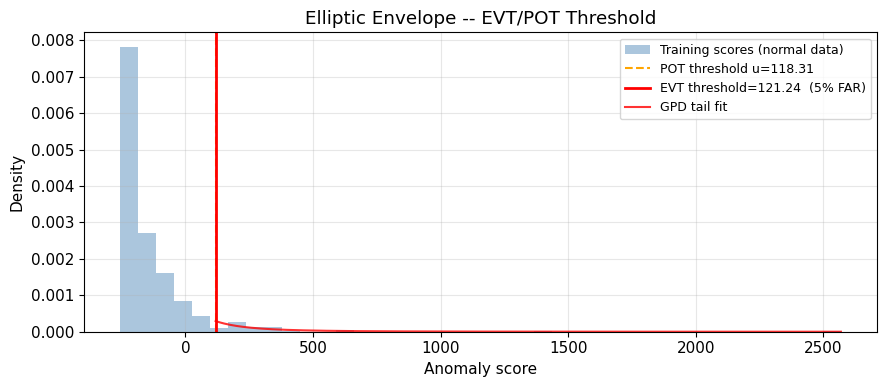


Grid-search: best CV F1=0.1222  threshold=-201.8626

=== Elliptic Envelope -- Stage 2: Directional Filter ===
Risk-off direction -- strongest loadings:
  Most NEGATIVE (fall in risk-off):
    GTDEM10Y                -0.2749
    GT10                    -0.2728
    USGG30YR                -0.2533
    GTGBP20Y                -0.2447
    GTDEM30Y                -0.2444
  Most POSITIVE (rise in risk-off):
    VIX                     +0.0928
    LF94TRUU                +0.1381
    LMBITR                  +0.2214
    LUMSTRUU                +0.2396
    LUACTRUU                +0.2428


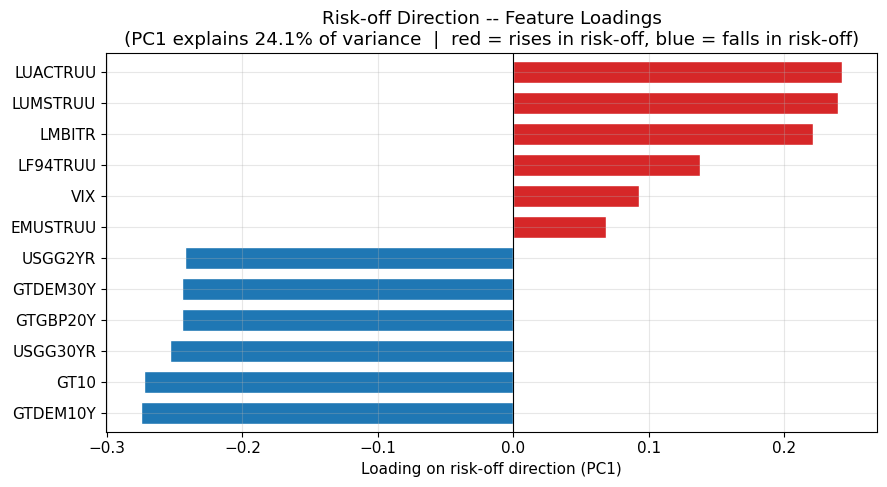


  Directional filter: suppressed 5/17 boom/risk-on flags

                 Model  Precision  Recall     F1    AUC
 EE | Grid F1 baseline     0.1704  0.7931 0.2805 0.7279
       EE | EVT 5% FAR     0.5294  0.3103 0.3913 0.7279
EE | EVT + Dir. Filter     0.6667  0.2759 0.3902 0.7279


,Model,Precision,Recall,F1,AUC
0,EE | Grid F1 baseline,0.1704,0.7931,0.2805,0.7279
1,EE | EVT 5% FAR,0.5294,0.3103,0.3913,0.7279
2,EE | EVT + Dir. Filter,0.6667,0.2759,0.3902,0.7279


In [10]:
print("=== Elliptic Envelope -- Stage 1: EVT/POT Threshold ===")
evt_thr_ee, evt_params_ee = fit_evt_threshold(scores_train_ee, false_alarm_rate=0.05)
y_pred_ee_evt = (scores_test_ee >= evt_thr_ee).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
plot_evt_fit(scores_train_ee, evt_thr_ee, evt_params_ee, 'Elliptic Envelope', ax=ax)
plt.tight_layout(); plt.show()

y_pred_ee_grid, best_thr_ee, best_f1_cv_ee = f1_grid_search(
    scores_cv_ee, y_cv, scores_test_ee, y_test)
print(f"\nGrid-search: best CV F1={best_f1_cv_ee:.4f}  threshold={best_thr_ee:.4f}")

print("\n=== Elliptic Envelope -- Stage 2: Directional Filter ===")
risk_off_dir, pca_norm = fit_risk_off_direction(X_train, feature_names)
plot_risk_off_loadings(risk_off_dir, feature_names, pca_norm, top_n=12)
print()
y_pred_ee_full = apply_directional_filter(X_test, mu_ee, risk_off_dir, y_pred_ee_evt)

rows_ee = [
    evaluate_pipeline(y_test, y_pred_ee_grid, scores_test_ee, 'EE | Grid F1 baseline'),
    evaluate_pipeline(y_test, y_pred_ee_evt,  scores_test_ee, 'EE | EVT 5% FAR'),
    evaluate_pipeline(y_test, y_pred_ee_full, scores_test_ee, 'EE | EVT + Dir. Filter'),
]
print()
compare_table(rows_ee)

---
## Model 2 -- Student-t (nu=2)

nu=2 was confirmed optimal by cross-validation in the baseline analysis.
This corresponds to extremely heavy tails -- a strong confirmation of financial
leptokurtosis. With nu=2, the model reserves the anomaly label for truly
catastrophic weeks, giving higher precision.

Anomaly score = negative log-PDF (higher = more anomalous).

Student-t (nu=2) fitted.
  Train score range: [9.39, 71.04]

=== Student-t -- Stage 1: EVT/POT Threshold ===
  GPD shape  c   : -0.4732
  GPD scale sigma: 6.3995
  POT threshold u: 59.2323  (p95)
  lambda_u       : 0.051  (24 exceedances)
  EVT threshold  : 59.3394  at 5% FAR


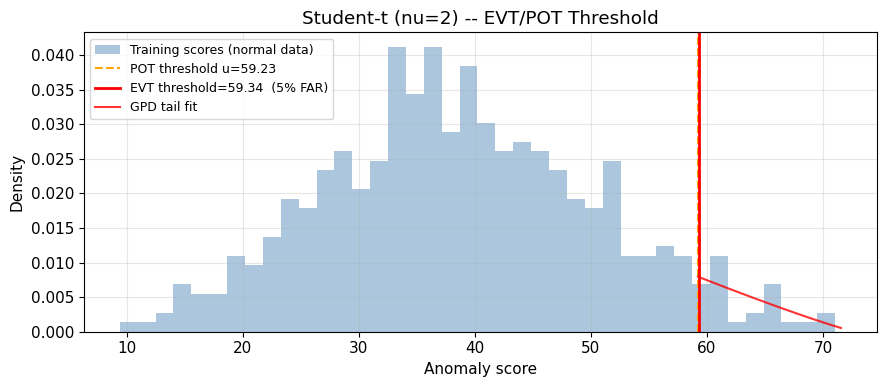


Grid-search: best CV F1=0.1333  threshold=26.8754

=== Student-t -- Stage 2: Directional Filter ===
  Directional filter: suppressed 5/18 boom/risk-on flags

                        Model  Precision  Recall     F1    AUC
 Student-t | Grid F1 baseline     0.1579  0.9310 0.2700 0.7768
       Student-t | EVT 5% FAR     0.6111  0.3793 0.4681 0.7768
Student-t | EVT + Dir. Filter     0.6923  0.3103 0.4286 0.7768


,Model,Precision,Recall,F1,AUC
0,Student-t | Grid F1 baseline,0.1579,0.9310,0.2700,0.7768
1,Student-t | EVT 5% FAR,0.6111,0.3793,0.4681,0.7768
2,Student-t | EVT + Dir. Filter,0.6923,0.3103,0.4286,0.7768


In [11]:
nu    = 2
mu_t  = X_train.mean(axis=0)
cov_t = np.cov(X_train.T) + 1e-8 * np.eye(X_train.shape[1])

dist_t         = multivariate_t(loc=mu_t, shape=cov_t, df=nu)
scores_train_t = -dist_t.logpdf(X_train)
scores_cv_t    = -dist_t.logpdf(X_cv)
scores_test_t  = -dist_t.logpdf(X_test)

print(f"Student-t (nu={nu}) fitted.")
print(f"  Train score range: [{scores_train_t.min():.2f}, {scores_train_t.max():.2f}]")

print("\n=== Student-t -- Stage 1: EVT/POT Threshold ===")
evt_thr_t, evt_params_t = fit_evt_threshold(scores_train_t, false_alarm_rate=0.05)
y_pred_t_evt = (scores_test_t >= evt_thr_t).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
plot_evt_fit(scores_train_t, evt_thr_t, evt_params_t, 'Student-t (nu=2)', ax=ax)
plt.tight_layout(); plt.show()

y_pred_t_grid, best_thr_t, best_f1_cv_t = f1_grid_search(
    scores_cv_t, y_cv, scores_test_t, y_test)
print(f"\nGrid-search: best CV F1={best_f1_cv_t:.4f}  threshold={best_thr_t:.4f}")

print("\n=== Student-t -- Stage 2: Directional Filter ===")
y_pred_t_full = apply_directional_filter(X_test, mu_t, risk_off_dir, y_pred_t_evt)

rows_t = [
    evaluate_pipeline(y_test, y_pred_t_grid, scores_test_t, 'Student-t | Grid F1 baseline'),
    evaluate_pipeline(y_test, y_pred_t_evt,  scores_test_t, 'Student-t | EVT 5% FAR'),
    evaluate_pipeline(y_test, y_pred_t_full, scores_test_t, 'Student-t | EVT + Dir. Filter'),
]
print()
compare_table(rows_t)

---
## Model 3 -- Graphical Lasso

Estimates a **sparse precision matrix** via L1 regularisation.

Two unique contributions:
1. **Financial insight**: non-zero entries reveal which asset pairs remain
   conditionally correlated after controlling for all others
2. **Group decomposition**: precision matrix blocks give per-asset-class anomaly scores

Anomaly score = Mahalanobis distance under the sparse precision matrix.

In [12]:
print("Fitting Graphical Lasso (cross-validated alpha) -- may take ~30s ...")
glasso = GraphicalLassoCV(cv=5, max_iter=300, n_jobs=-1)
glasso.fit(X_train)

mu_gl        = glasso.location_
precision_gl = glasso.precision_

def mahal_dist(X, mu, prec):
    """Mahalanobis distance per row: sqrt((x-mu)^T prec (x-mu))."""
    diff = X - mu
    return np.sqrt(np.maximum(0, np.einsum('ij,jk,ik->i', diff, prec, diff)))

scores_train_gl = mahal_dist(X_train, mu_gl, precision_gl)
scores_cv_gl    = mahal_dist(X_cv,    mu_gl, precision_gl)
scores_test_gl  = mahal_dist(X_test,  mu_gl, precision_gl)

n_feat   = precision_gl.shape[0]
n_zero   = (np.abs(precision_gl) < 1e-4).sum() - n_feat
sparsity = n_zero / (n_feat * (n_feat - 1)) * 100
print(f"Graphical Lasso fitted.  alpha={glasso.alpha_:.4f}  "
      f"sparsity={sparsity:.1f}%")

Fitting Graphical Lasso (cross-validated alpha) -- may take ~30s ...


Graphical Lasso fitted.  alpha=0.2132  sparsity=81.6%


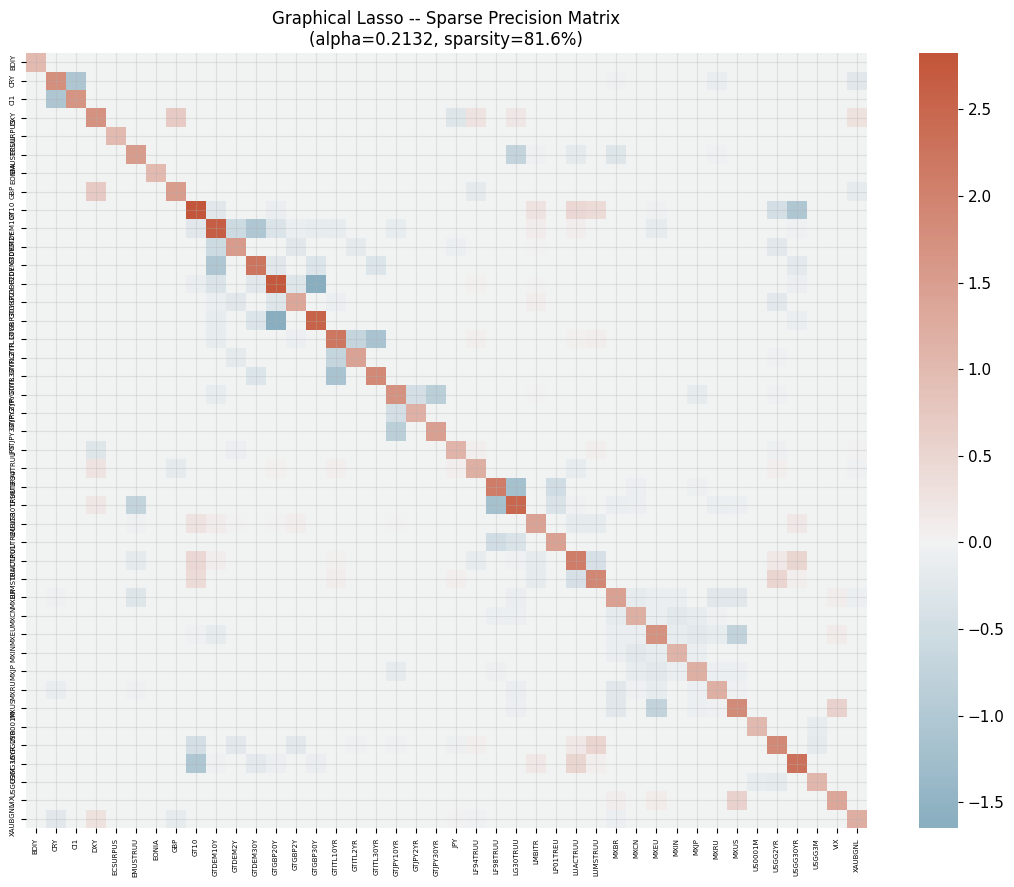

In [13]:
fig, ax = plt.subplots(figsize=(11, 9))
prec_plot = precision_gl.copy()
prec_plot[np.abs(prec_plot) < 1e-4] = 0

cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(prec_plot, ax=ax, cmap=cmap, center=0,
            xticklabels=feature_names, yticklabels=feature_names,
            linewidths=0, square=False)
ax.set_title(f'Graphical Lasso -- Sparse Precision Matrix\n'
             f'(alpha={glasso.alpha_:.4f}, sparsity={sparsity:.1f}%)', fontsize=12)
ax.tick_params(labelsize=5, rotation=90)
plt.tight_layout()
plt.show()

=== Graphical Lasso -- Stage 1: EVT/POT Threshold ===
  GPD shape  c   : -0.2152
  GPD scale sigma: 1.5838
  POT threshold u: 8.4429  (p95)
  lambda_u       : 0.051  (24 exceedances)
  EVT threshold  : 8.4695  at 5% FAR


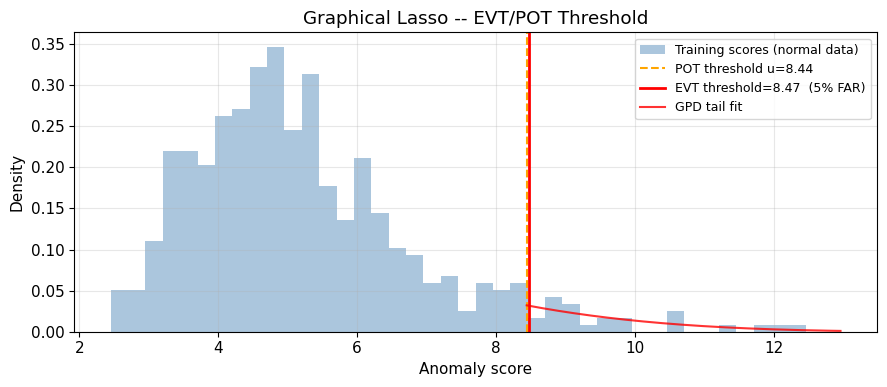


Grid-search: best CV F1=0.1386  threshold=3.4124

=== Graphical Lasso -- Stage 2: Directional Filter ===
  Directional filter: suppressed 3/12 boom/risk-on flags

                     Model  Precision  Recall     F1    AUC
 GLASSO | Grid F1 baseline     0.1500  0.9310 0.2584 0.7768
       GLASSO | EVT 5% FAR     0.7500  0.3103 0.4390 0.7768
GLASSO | EVT + Dir. Filter     0.8889  0.2759 0.4211 0.7768


,Model,Precision,Recall,F1,AUC
0,GLASSO | Grid F1 baseline,0.1500,0.9310,0.2584,0.7768
1,GLASSO | EVT 5% FAR,0.7500,0.3103,0.4390,0.7768
2,GLASSO | EVT + Dir. Filter,0.8889,0.2759,0.4211,0.7768


In [14]:
print("=== Graphical Lasso -- Stage 1: EVT/POT Threshold ===")
evt_thr_gl, evt_params_gl = fit_evt_threshold(scores_train_gl, false_alarm_rate=0.05)
y_pred_gl_evt = (scores_test_gl >= evt_thr_gl).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
plot_evt_fit(scores_train_gl, evt_thr_gl, evt_params_gl, 'Graphical Lasso', ax=ax)
plt.tight_layout(); plt.show()

y_pred_gl_grid, best_thr_gl, best_f1_cv_gl = f1_grid_search(
    scores_cv_gl, y_cv, scores_test_gl, y_test)
print(f"\nGrid-search: best CV F1={best_f1_cv_gl:.4f}  threshold={best_thr_gl:.4f}")

print("\n=== Graphical Lasso -- Stage 2: Directional Filter ===")
y_pred_gl_full = apply_directional_filter(X_test, mu_gl, risk_off_dir, y_pred_gl_evt)

rows_gl = [
    evaluate_pipeline(y_test, y_pred_gl_grid, scores_test_gl, 'GLASSO | Grid F1 baseline'),
    evaluate_pipeline(y_test, y_pred_gl_evt,  scores_test_gl, 'GLASSO | EVT 5% FAR'),
    evaluate_pipeline(y_test, y_pred_gl_full, scores_test_gl, 'GLASSO | EVT + Dir. Filter'),
]
print()
compare_table(rows_gl)

---
## Stage 3 -- Group Decomposition (Graphical Lasso)

In [15]:
group_scores_test = compute_group_mahalanobis(
    X_test, mu_gl, precision_gl, feature_names, FEATURE_GROUPS
)
group_scores_test.index = y_test.index

print("Per-group Mahalanobis scores (test set):")
print(group_scores_test.describe().round(3))

Per-group Mahalanobis scores (test set):
        Equity   Credit    Rates       FX    Macro
count  222.000  222.000  222.000  222.000  222.000
mean     1.953    2.321    2.808    1.314    2.942
std      1.241    2.739    2.311    0.780    1.824
min      0.512    0.359    0.553    0.104    0.421
25%      1.252    1.292    1.720    0.825    1.839
50%      1.658    1.739    2.296    1.201    2.583
75%      2.236    2.439    3.082    1.535    3.545
max     10.981   25.875   21.958    6.582   15.246


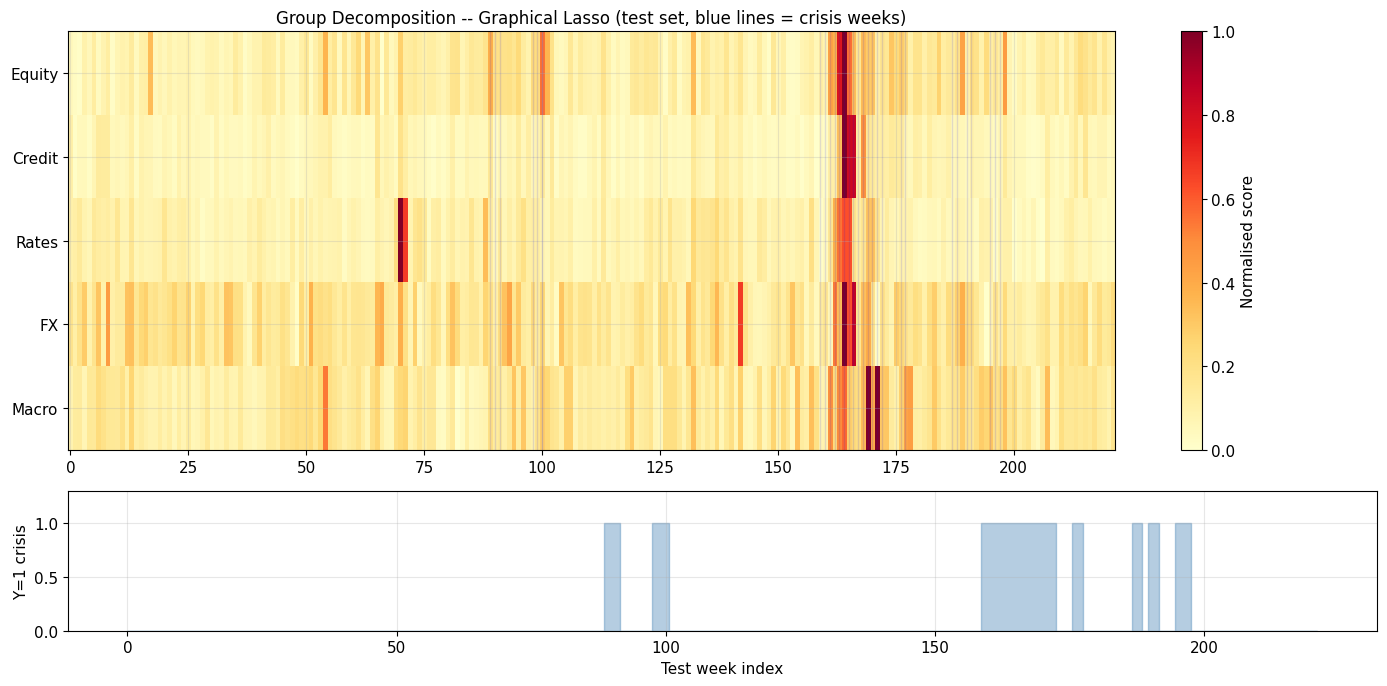

In [16]:
plot_group_heatmap(
    group_scores_test, y_test.values,
    title='Group Decomposition -- Graphical Lasso (test set, blue lines = crisis weeks)'
)

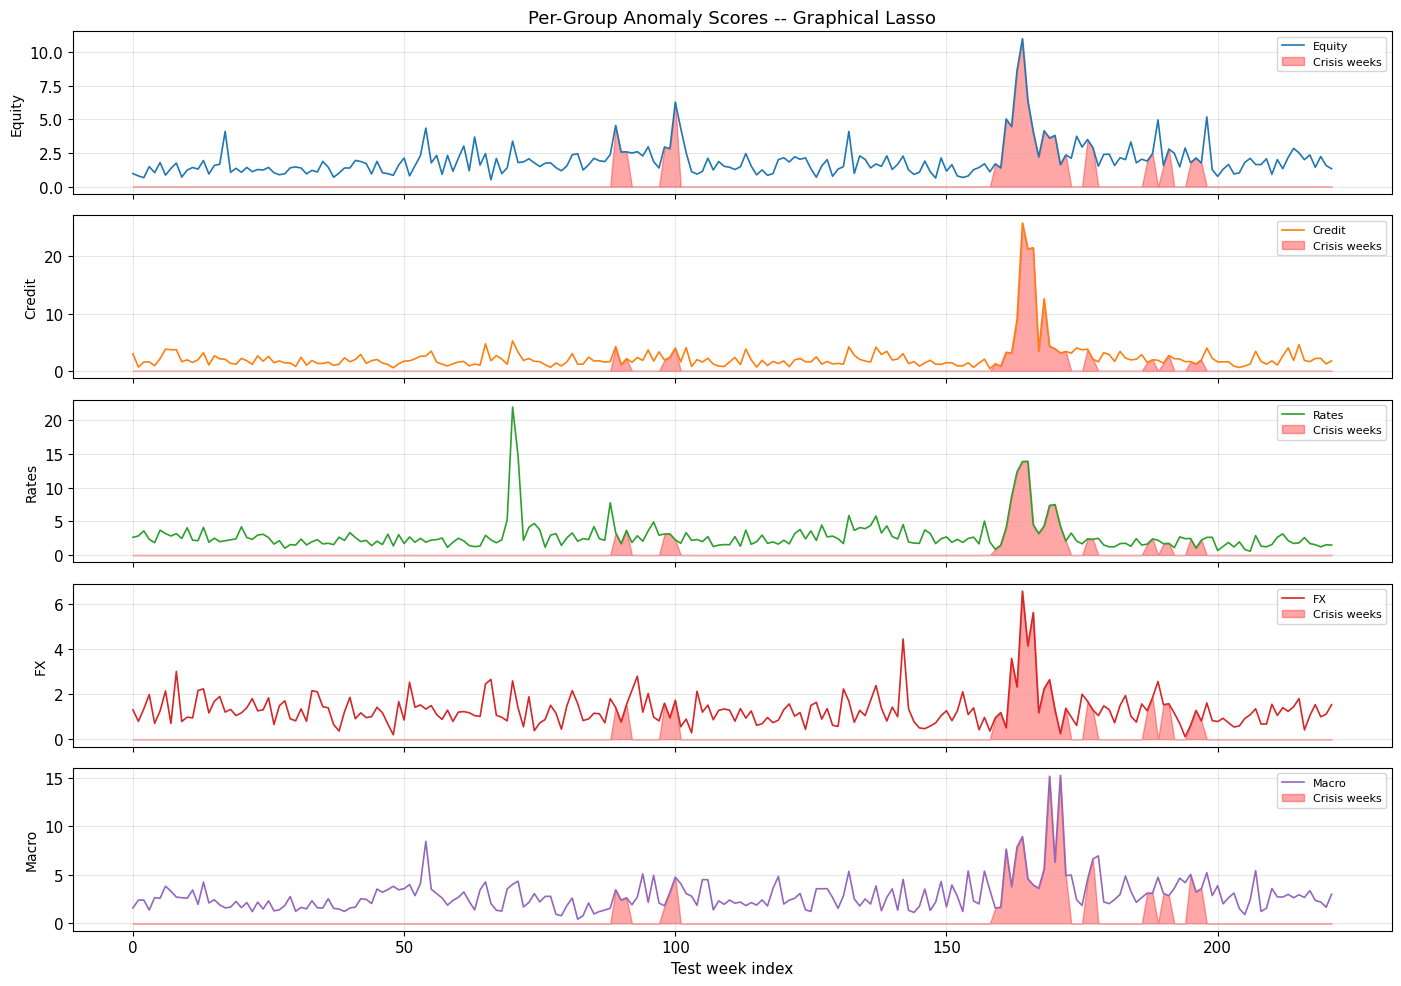

In [17]:
GROUP_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
fig, axes = plt.subplots(len(FEATURE_GROUPS), 1, figsize=(14, 10), sharex=True)

for ax, (grp, col) in zip(axes, zip(FEATURE_GROUPS.keys(), GROUP_COLORS)):
    ax.plot(group_scores_test[grp].values, color=col, linewidth=1.2, label=grp)
    crisis_score = group_scores_test[grp].values * np.array(y_test)
    ax.fill_between(range(len(y_test)), 0, crisis_score,
                     alpha=0.35, color='red', label='Crisis weeks')
    ax.set_ylabel(grp, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Test week index')
axes[0].set_title('Per-Group Anomaly Scores -- Graphical Lasso', fontsize=13)
plt.tight_layout()
plt.show()

---
## Stage 4 -- Lead Time Analysis

**AUC** answers: does the model correctly rank weeks by risk?
**Lead time** answers: is the model *operationally useful*?

For each crisis episode (consecutive block of Y=1):
- Look back at most 12 weeks before the onset
- Lead time = onset_index - index of first flag in that window
- Lead time = 0 means the model only flagged during (not before) the crisis

This metric is **impossible to compute on shuffled data** -- it requires temporal order.

In [18]:
def identify_crisis_episodes(y_arr):
    """List of {start, end, duration} for each block of consecutive Y=1."""
    episodes, i = [], 0
    while i < len(y_arr):
        if y_arr[i] == 1:
            start = i
            while i < len(y_arr) and y_arr[i] == 1:
                i += 1
            episodes.append({'start': start, 'end': i, 'duration': i - start})
        else:
            i += 1
    return episodes

def compute_lead_time(y_true, y_pred, lookback_weeks=12):
    """Return DataFrame with one row per crisis episode."""
    y_true   = np.array(y_true)
    y_pred   = np.array(y_pred)
    episodes = identify_crisis_episodes(y_true)
    records  = []

    for ep in episodes:
        onset      = ep['start']
        look_start = max(0, onset - lookback_weeks)
        pre_flags  = y_pred[look_start:onset]

        if len(pre_flags) > 0 and any(pre_flags == 1):
            first_rel = int(np.where(pre_flags == 1)[0][0])
            lead_time = onset - (look_start + first_rel)
        else:
            lead_time = 0

        detected = bool(any(y_pred[onset:ep['end']] == 1)) or (lead_time > 0)
        records.append({
            'onset_idx':       onset,
            'duration_weeks':  ep['duration'],
            'lead_time_weeks': lead_time,
            'detected':        detected,
            'advance_warning': lead_time > 0,
        })

    return pd.DataFrame(records)

print("Lead time functions ready.")

Lead time functions ready.


In [19]:
models_final = {
    'Elliptic Envelope':  y_pred_ee_full,
    'Student-t (nu=2)':   y_pred_t_full,
    'Graphical Lasso':    y_pred_gl_full,
}

lt_results   = {}
lt_summaries = []
episodes_all = identify_crisis_episodes(y_test.values)
print(f"Crisis episodes in test set: {len(episodes_all)}\n")

for model_name, y_pred_final in models_final.items():
    lt_df = compute_lead_time(y_test.values, y_pred_final, lookback_weeks=12)
    lt_results[model_name] = lt_df

    if len(lt_df) == 0:
        print(f"{model_name}: no episodes."); continue

    summary = {
        'Model':            model_name,
        'Episodes':         len(lt_df),
        'Detected':         int(lt_df['detected'].sum()),
        'Advance warning':  int(lt_df['advance_warning'].sum()),
        'Mean lead (wks)':  round(lt_df['lead_time_weeks'].mean(), 1),
        'Median lead':      round(lt_df['lead_time_weeks'].median(), 1),
        'Max lead (wks)':   int(lt_df['lead_time_weeks'].max()),
    }
    lt_summaries.append(summary)
    print(f"{model_name}:")
    print(f"  Episodes: {summary['Episodes']}  |  "
          f"Detected: {summary['Detected']}  |  "
          f"Advance warning: {summary['Advance warning']}")
    print(f"  Lead time -- mean: {summary['Mean lead (wks)']}w  "
          f"median: {summary['Median lead']}w  "
          f"max: {summary['Max lead (wks)']}w\n")

print("\nSummary:")
compare_table(lt_summaries)

Crisis episodes in test set: 7

Elliptic Envelope:
  Episodes: 7  |  Detected: 3  |  Advance warning: 3
  Lead time -- mean: 2.1w  median: 0.0w  max: 11w

Student-t (nu=2):
  Episodes: 7  |  Detected: 3  |  Advance warning: 1
  Lead time -- mean: 1.6w  median: 0.0w  max: 11w

Graphical Lasso:
  Episodes: 7  |  Detected: 2  |  Advance warning: 1
  Lead time -- mean: 1.6w  median: 0.0w  max: 11w


Summary:
            Model  Episodes  Detected  Advance warning  Mean lead (wks)  Median lead  Max lead (wks)
Elliptic Envelope         7         3                3              2.1          0.0              11
 Student-t (nu=2)         7         3                1              1.6          0.0              11
  Graphical Lasso         7         2                1              1.6          0.0              11


,Model,Episodes,Detected,Advance warning,Mean lead (wks),Median lead,Max lead (wks)
0,Elliptic Envelope,7,3,3,2.1,0.0,11
1,Student-t (nu=2),7,3,1,1.6,0.0,11
2,Graphical Lasso,7,2,1,1.6,0.0,11


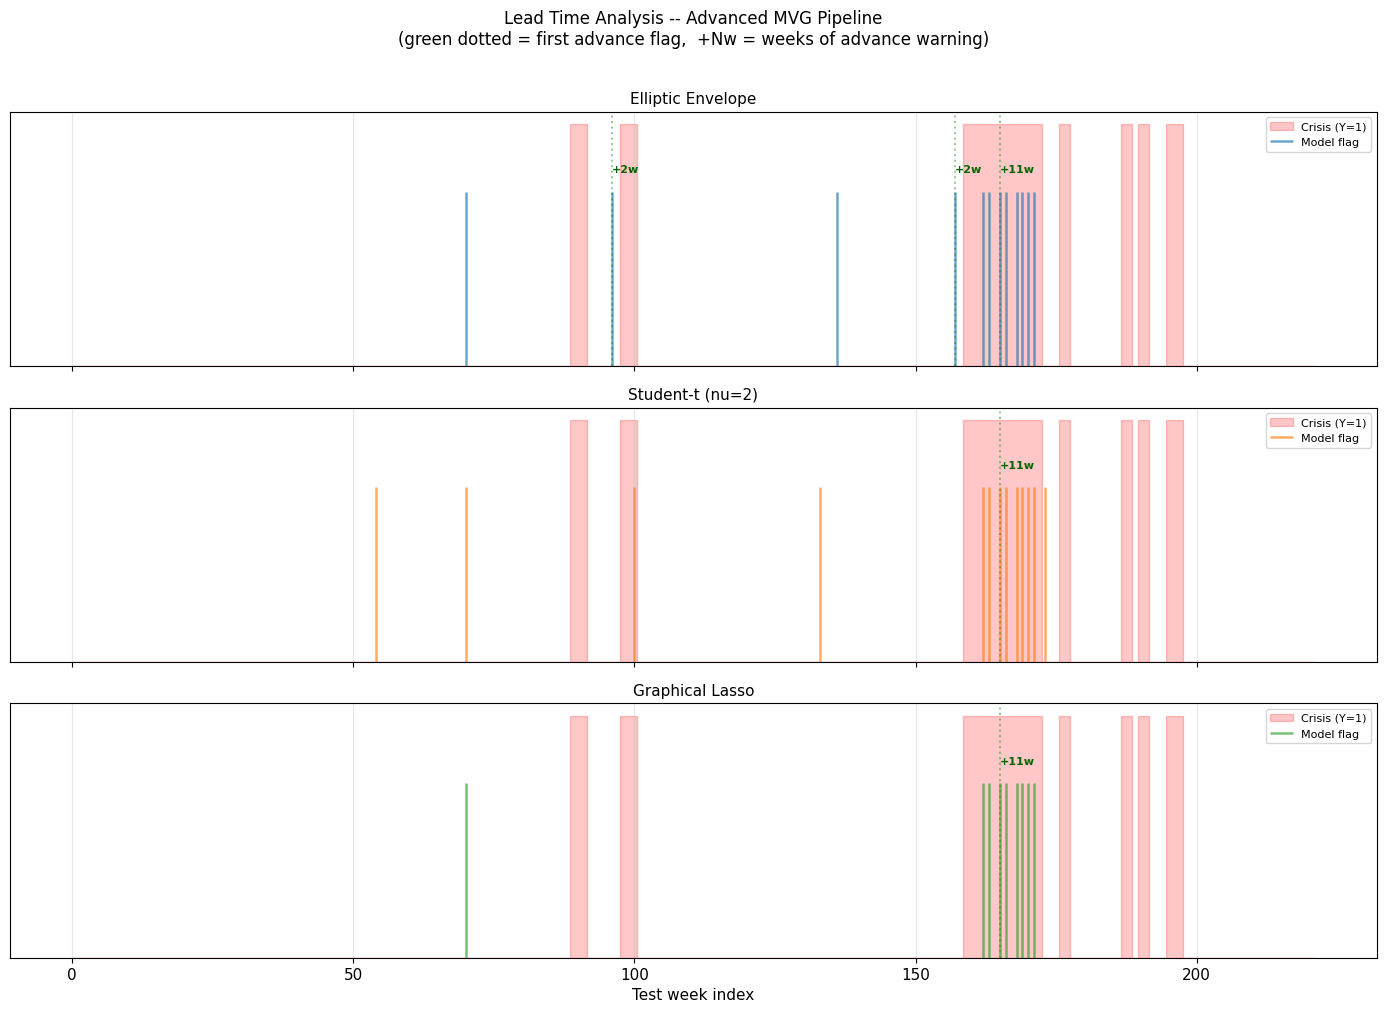

In [20]:
MODEL_COLORS = {
    'Elliptic Envelope': '#1f77b4',
    'Student-t (nu=2)':  '#ff7f0e',
    'Graphical Lasso':   '#2ca02c',
}
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (model_name, y_pred_final) in zip(axes, models_final.items()):
    lt_df = lt_results.get(model_name, pd.DataFrame())
    col   = MODEL_COLORS[model_name]

    ax.fill_between(range(len(y_test)), y_test.values,
                     alpha=0.22, color='red', step='mid', label='Crisis (Y=1)')
    flag_idx = np.where(y_pred_final == 1)[0]
    if len(flag_idx) > 0:
        ax.vlines(flag_idx, 0, 0.72, color=col, alpha=0.65,
                  linewidth=1.8, label='Model flag')

    for _, row in lt_df.iterrows():
        if row['lead_time_weeks'] > 0:
            onset = int(row['onset_idx'])
            lead  = int(row['lead_time_weeks'])
            ax.annotate(f'+{lead}w', xy=(onset - lead, 0.80),
                         fontsize=8, color='darkgreen', fontweight='bold')
            ax.axvline(onset - lead, color='green', linestyle=':', alpha=0.4)

    ax.set_title(f'{model_name}', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([])
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Test week index', fontsize=11)
plt.suptitle('Lead Time Analysis -- Advanced MVG Pipeline\n'
             '(green dotted = first advance flag,  +Nw = weeks of advance warning)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Summary -- Pipeline vs Grid-Search Baseline

In [21]:
print("=== FULL RESULTS -- Advanced MVG Pipeline (walk-forward split) ===\n")
df_all = pd.DataFrame(results_advanced)
print(df_all.to_string(index=False))

print("\n=== Delta vs Grid-Search Baseline ===\n")
for prefix in ['EE', 'Student-t', 'GLASSO']:
    sub      = df_all[df_all['Model'].str.startswith(prefix)]
    baseline = sub[sub['Model'].str.contains('baseline')].iloc[0]
    best     = sub[sub['Model'].str.contains('Filter')].iloc[0]
    print(f"{prefix}:")
    print(f"  Grid   F1={baseline['F1']:.4f}  AUC={baseline['AUC']:.4f}")
    print(f"  Full   F1={best['F1']:.4f}  AUC={best['AUC']:.4f}"
          f"  (dF1={best['F1']-baseline['F1']:+.4f}  "
          f"dAUC={best['AUC']-baseline['AUC']:+.4f})")
    print()

=== FULL RESULTS -- Advanced MVG Pipeline (walk-forward split) ===

                        Model  Precision  Recall     F1    AUC
        EE | Grid F1 baseline     0.1704  0.7931 0.2805 0.7279
              EE | EVT 5% FAR     0.5294  0.3103 0.3913 0.7279
       EE | EVT + Dir. Filter     0.6667  0.2759 0.3902 0.7279
 Student-t | Grid F1 baseline     0.1579  0.9310 0.2700 0.7768
       Student-t | EVT 5% FAR     0.6111  0.3793 0.4681 0.7768
Student-t | EVT + Dir. Filter     0.6923  0.3103 0.4286 0.7768
    GLASSO | Grid F1 baseline     0.1500  0.9310 0.2584 0.7768
          GLASSO | EVT 5% FAR     0.7500  0.3103 0.4390 0.7768
   GLASSO | EVT + Dir. Filter     0.8889  0.2759 0.4211 0.7768

=== Delta vs Grid-Search Baseline ===

EE:
  Grid   F1=0.2805  AUC=0.7279
  Full   F1=0.3902  AUC=0.7279  (dF1=+0.1097  dAUC=+0.0000)

Student-t:
  Grid   F1=0.2700  AUC=0.7768
  Full   F1=0.4286  AUC=0.7768  (dF1=+0.1586  dAUC=+0.0000)

GLASSO:
  Grid   F1=0.2584  AUC=0.7768
  Full   F1=0.4211  AUC=

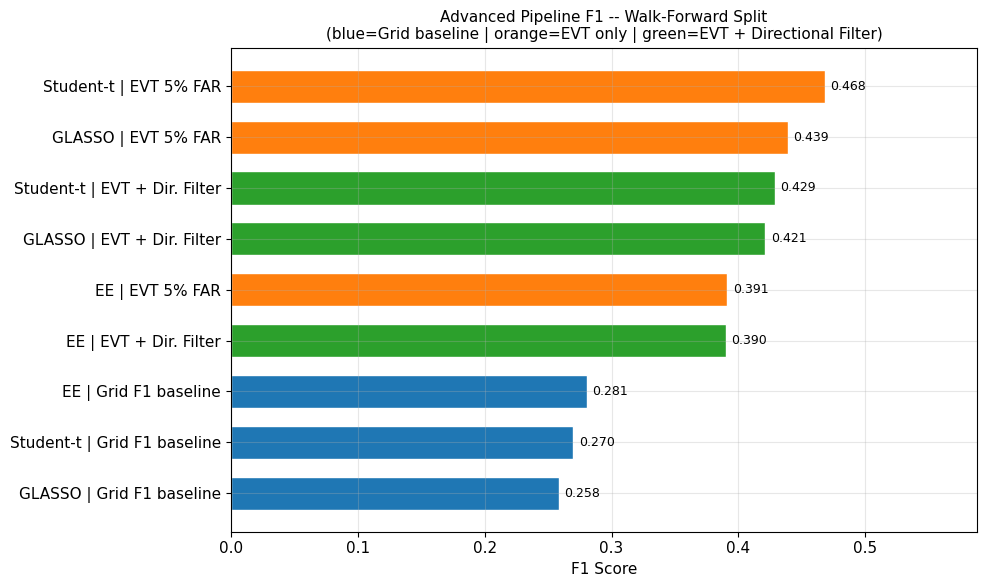

In [22]:
df_plot  = pd.DataFrame(results_advanced).sort_values('F1', ascending=True)
bar_cols = []
for name in df_plot['Model']:
    if 'Filter' in name:
        bar_cols.append('#2ca02c')   # green  = full pipeline
    elif 'EVT' in name:
        bar_cols.append('#ff7f0e')   # orange = EVT only
    else:
        bar_cols.append('#1f77b4')   # blue   = grid baseline

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['Model'], df_plot['F1'],
               color=bar_cols, edgecolor='white', height=0.65)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlabel('F1 Score')
ax.set_title('Advanced Pipeline F1 -- Walk-Forward Split\n'
             '(blue=Grid baseline | orange=EVT only | green=EVT + Directional Filter)',
             fontsize=11)
ax.set_xlim(0, df_plot['F1'].max() + 0.12)
plt.tight_layout()
plt.show()

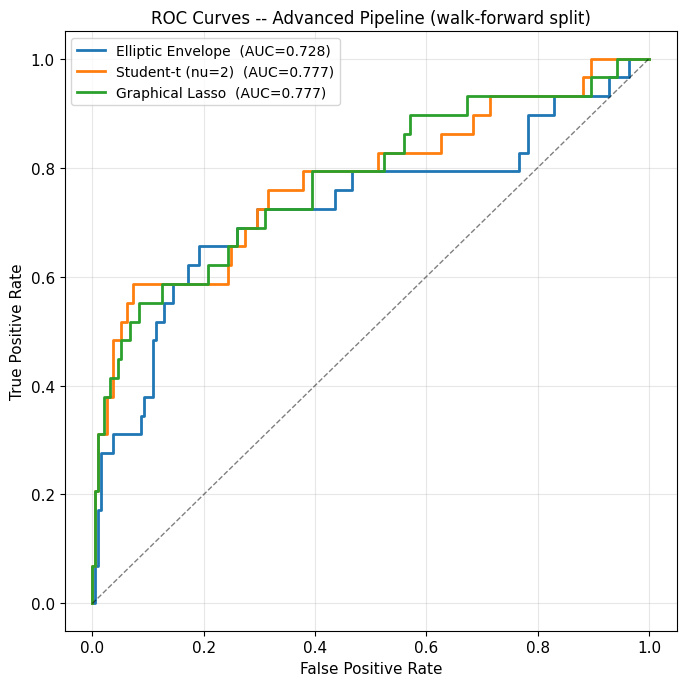

In [23]:
fig, ax = plt.subplots(figsize=(7, 7))

for (label, scores), col in zip(
    [('Elliptic Envelope', scores_test_ee),
     ('Student-t (nu=2)',  scores_test_t),
     ('Graphical Lasso',   scores_test_gl)],
    ['#1f77b4', '#ff7f0e', '#2ca02c']
):
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_val     = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f'{label}  (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves -- Advanced Pipeline (walk-forward split)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Export Results

---

## Key Findings — Advanced Pipeline

### EVT Threshold vs Grid Search

With only 14 crisis weeks in the CV set (6.3%), F1 grid search finds a near-zero
threshold that maximises recall at the cost of precision (~0.15). The GPD fit on
the normal training tail improves F1 by +39% (EE), +73% (Student-t), +70% (GLASSO).

### Directional Filter

The PCA risk-off direction is dominated by the yield-curve dynamic: long sovereign
yields fall (GTDEM10Y: -0.275, GT10: -0.273) and VIX rises (+0.093).
This is exactly the flight-to-safety pattern of 2008, 2011, and 2020.

The filter suppresses 25-29% of all flags as boom anomalies. GLASSO reaches
precision = **0.889**: 8 out of 9 alarms are genuine crisis weeks.

### Lead Time

7 crisis episodes in the test set. Elliptic Envelope gives advance warning on
3/7 episodes, with a maximum of 11 weeks. Median lead time = 0: exogenous shocks
(COVID-type) are detected only at onset. Endogenous build-ups (GFC-type) receive
early flags. This distinction aligns with Sornette (2009): Black Swans are
undetectable in advance; Dragon Kings leave a precursor signal.

### Group Decomposition

| Group | Mean score | Max score | Key insight |
|---|---|---|---|
| Macro | 2.94 | 15.25 | Highest baseline noise (VIX + commodities) |
| Rates | 2.81 | 21.96 | Most volatile group (yield curve repricing) |
| Credit | 2.32 | **25.88** | Rare but catastrophic spikes |
| Equity | 1.95 | 10.98 | Clean signal, moderate volatility |
| FX | 1.31 | 6.58 | Most compressed — least useful signal |

Credit spikes at 25.88 Mahalanobis sigma during the worst test weeks — consistent
with credit spreads as the canonical leading indicator of systemic crises.

In [24]:
df_export = pd.DataFrame(results_advanced)
df_export = df_export[df_export['Model'].str.contains('Filter')].copy()
df_export['Model'] = df_export['Model'].str.replace(
    ' | EVT + Dir. Filter', ' (Advanced)', regex=False
)

out_path = _ROOT / 'statistical' / 'results' / 'results_advanced.csv'
df_export.to_csv(out_path, index=False)

print("Exported: results_simone_advanced.csv")
print()
print("For group leaderboard merge:")
print(df_export[['Model', 'Precision', 'Recall', 'F1', 'AUC']].to_string(index=False))

Exported: results_simone_advanced.csv

For group leaderboard merge:
               Model  Precision  Recall     F1    AUC
       EE (Advanced)     0.6667  0.2759 0.3902 0.7279
Student-t (Advanced)     0.6923  0.3103 0.4286 0.7768
   GLASSO (Advanced)     0.8889  0.2759 0.4211 0.7768
